<a id="title"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:20px 20px;">**Sectional Area Extraction**</p>

## Method Overview

This notebook implements the **first sub-task of Block 2 — Geometric Stenosis Quantification**: computing the **cross-sectional lumen area** at every centerline point for a single patient (both RCA and LCA).

### Why cross-sectional area?

Clinically, stenosis is defined by how much the lumen shrinks relative to a healthy reference (CAD-RADS, Ela Burrull's pipeline). The Block 1 radius (`MaximumInscribedSphereRadius`) is only a 1D proxy — it equals the true section radius only when the lumen is a perfect circle. The true metric is the **2D polygonal area** obtained by slicing the surface mesh with a plane perpendicular to the centerline tangent at each point. That is the quantity this notebook produces and hands off to the downstream %DS / %AS computation.

### Inputs (from Block 1)

| Input | Source | Role |
|-------|--------|------|
| Centerline dataframe | `results/block1_results/dataframes/df_<Patient>_<date>.{xlsx,csv}` | Row-aligned table we enrich with the new `Area` column |
| Centerline polydata  | `results/block1_results/centerlines/centerline_<Patient>_<Artery>_<date>.vtp` | VTK polyline + `MaximumInscribedSphereRadius`; required by `vmtkCenterlineSections` |
| Binary mask          | `data/ASOCA Normal/Annotations/<Patient>.nrrd` | Only needed because Block 1 does **not** currently persist the smoothed surface mesh — we rebuild it here with Block 1's exact Marching-Cubes + Taubin-smoothing parameters so geometry is bit-identical |

### Algorithm

`vmtkCenterlineSections` builds a plane perpendicular to the centerline tangent at each point, intersects it with the surface mesh, computes the polygonal cross-section, and attaches per-point arrays to the centerline (primarily `CenterlineSectionArea` in mm² and `CenterlineSectionClosed`). The details of each array and of the robustness policy for non-closed sections are in Section 3.

### Notebook layout

| Section | What it does |
|---------|--------------|
| 1 — Imports & Configuration | Python / VMTK setup, patient & path configuration |
| 2 — Data Loading & Mesh Preparation | Load centerline dataframe + `.vtp`, rebuild smoothed surface from the NRRD mask, verify coordinate alignment |
| 3 — Cross-Sectional Area Computation | Defensive preprocessing + `vmtkCenterlineSections` per artery |
| 4 — DataFrame Integration | Merge `Area` into the Block 1 dataframe (row-aligned or KDTree fallback) and run numeric sanity checks |
| 5 — Visual Validation | 3D overview (mesh + area-colored centerline) and 2D cross-section QA plots for healthy / narrow / random picks, with a dedicated interpretation subsection |
| 6 — Export Enriched DataFrame | Persist the final table to `results/block2_results/dataframes/` |

<a id="step1"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">1. Imports & Configuration</p>

In [1]:
import sys
import types
from pathlib import Path

import numpy as np
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
from vmtk import vmtkscripts

# The vmtk conda-forge build strips vtkRenderingMatplotlib.
# Inject a dummy so PyVista skips it gracefully.
sys.modules.setdefault(
    "vtkmodules.vtkRenderingMatplotlib",
    types.ModuleType("vtkmodules.vtkRenderingMatplotlib"),
)

# Make Block 1 helpers importable (mask loading + VTK image packing).
# `src/blocks/__init__.py` imports via the fully-qualified `src.blocks.*`
# path, so the project root (parent of `src/`) must be on sys.path.
PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.blocks._01_extraction import (
    load_and_separate_mask,
    _numpy_to_vtk_image,
)

In [2]:
PATIENT_ID = "Normal_1"

DATA_ROOT     = PROJECT_ROOT / "data" / "ASOCA Normal"
NRRD_PATH     = DATA_ROOT / "Annotations" / f"{PATIENT_ID}.nrrd"

B1_ROOT       = PROJECT_ROOT / "results" / "block1_results"
B1_DF_DIR     = B1_ROOT / "dataframes"
B1_CL_DIR     = B1_ROOT / "centerlines"

B2_ROOT       = PROJECT_ROOT / "results" / "block2_results"
B2_DF_DIR     = B2_ROOT / "dataframes"
B2_DF_DIR.mkdir(parents=True, exist_ok=True)

for _backend in ("trame", "static"):
    try:
        pv.set_jupyter_backend(_backend)
        break
    except Exception:
        continue

print(f"Patient        : {PATIENT_ID}")
print(f"NRRD mask      : {NRRD_PATH}  (exists={NRRD_PATH.exists()})")
print(f"Block 1 df dir : {B1_DF_DIR}")
print(f"Block 1 cl dir : {B1_CL_DIR}")
print(f"Block 2 output : {B2_DF_DIR}")

Patient        : Normal_1
NRRD mask      : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\data\ASOCA Normal\Annotations\Normal_1.nrrd  (exists=True)
Block 1 df dir : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\dataframes
Block 1 cl dir : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block1_results\centerlines
Block 2 output : C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block2_results\dataframes


<a id="step2"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">2. Data Loading & Mesh Preparation</p>

We need three geometric inputs per artery to compute sections:

1. **Centerline DataFrame** (`.xlsx` preferred, `.csv` fallback): the authoritative row-aligned table we will enrich with the `Area` column.
2. **Centerline polydata** (`.vtp`): the VMTK centerline object **with line topology**. This is what `vmtkCenterlineSections` requires as input — a polydata, not a raw point cloud. We therefore load the `.vtp` file directly and cross-check its point count against the dataframe.
3. **Smoothed surface mesh** per artery: rebuilt here from the original `.nrrd` binary mask using Block 1's helpers, which guarantees the coordinate system matches exactly (same spacing, same origin, same Marching Cubes level, same Taubin passband). Once we update Block 1 to persist the `.vtp` mesh, this regeneration step will become a simple file load.

In [3]:
# ═══════════════════════════════════════════════════════════════
#  Helper functions: discovery & mesh reconstruction
# ═══════════════════════════════════════════════════════════════

def find_centerline_dataframe(df_dir: Path, patient_id: str) -> Path:
    """
    Auto-detect the Block 1 centerline table for a patient.

    Accepts both .xlsx and .csv.  If several exist, picks the most
    recently modified one (matches Block 1's overwrite-on-rerun convention).
    """
    candidates = list(df_dir.glob(f"df_{patient_id}_*.xlsx")) + \
                 list(df_dir.glob(f"df_{patient_id}_*.csv"))
    if not candidates:
        raise FileNotFoundError(
            f"No df_{patient_id}_*.xlsx / .csv in {df_dir}.  "
            "Run Block 1 for this patient first."
        )
    return max(candidates, key=lambda p: p.stat().st_mtime)


def load_centerline_dataframe(df_path: Path) -> pd.DataFrame:
    """Read an .xlsx or .csv centerline table with consistent dtypes."""
    if df_path.suffix.lower() == ".xlsx":
        df = pd.read_excel(df_path)
    elif df_path.suffix.lower() == ".csv":
        df = pd.read_csv(df_path)
    else:
        raise ValueError(f"Unsupported dataframe format: {df_path.suffix}")
    required = {"Patient_ID", "Artery_Type", "Px", "Py", "Pz", "Radius"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Dataframe is missing required columns: {missing}")
    return df


def find_centerline_vtp(cl_dir: Path, patient_id: str, artery_type: str) -> Path:
    """Return the newest centerline .vtp for a (patient, artery)."""
    matches = list(cl_dir.glob(f"centerline_{patient_id}_{artery_type}_*.vtp"))
    if not matches:
        raise FileNotFoundError(
            f"No centerline .vtp for {patient_id} / {artery_type} in {cl_dir}."
        )
    return max(matches, key=lambda p: p.stat().st_mtime)


def rebuild_smooth_surface(
    artery_mask: np.ndarray,
    spacing: np.ndarray,
    origin: np.ndarray,
    iterations: int = 20,
    passband: float = 0.1,
):
    """
    Rebuild a Taubin-smoothed surface mesh from a single-artery binary mask.

    Mirrors Block 1's mesh generation exactly so the surface used for
    sectioning is geometrically identical to the one used for centerlines.
    """
    vtk_artery = _numpy_to_vtk_image(artery_mask, spacing, origin)

    mc = vmtkscripts.vmtkMarchingCubes()
    mc.Image = vtk_artery
    mc.Level = 0.5
    mc.Execute()

    smoother = vmtkscripts.vmtkSurfaceSmoothing()
    smoother.Surface = mc.Surface
    smoother.NumberOfIterations = iterations
    smoother.PassBand = passband
    smoother.Execute()

    return smoother.Surface  # vtkPolyData


# ─────────────────────────────────────────────────────────────────────────
#  Defensive preprocessing for vmtkCenterlineSections
# ─────────────────────────────────────────────────────────────────────────
#
# `vmtkCenterlineSections` segfaults on:
#   • non-triangulated / duplicate-vertex surfaces  → slicing fails internally
#   • centerlines with coincident consecutive points → NaN tangent → NaN plane
#
# Block 1 centerlines carry 9 line cells with AppendEndPoints=1 and near-
# duplicate points (<1e-3 mm apart) which is exactly the scenario that
# crashes VMTK.  We harden both inputs before calling the script.

import vtk  # noqa: E402 — local to preprocessing helpers


def clean_triangulate_surface(surface):
    """Return a triangulated, duplicate-free copy of the input polydata."""
    tri = vtk.vtkTriangleFilter()
    tri.SetInputData(surface)
    tri.PassLinesOff()
    tri.PassVertsOff()
    tri.Update()

    clean = vtk.vtkCleanPolyData()
    clean.SetInputConnection(tri.GetOutputPort())
    clean.ConvertLinesToPointsOff()
    clean.ConvertPolysToLinesOff()
    clean.PointMergingOn()
    clean.Update()
    return clean.GetOutput()


def prepare_centerline_for_sections(centerlines, resample_step: float = 0.1,
                                    smoothing_iterations: int = 100,
                                    smoothing_factor: float = 0.1):
    """
    Smooth and uniformly resample a centerline so its tangents are always
    well-defined.  Returns a new polydata; the original is left untouched.
    """
    smooth = vmtkscripts.vmtkCenterlineSmoothing()
    smooth.Centerlines = centerlines
    smooth.NumberOfSmoothingIterations = smoothing_iterations
    smooth.SmoothingFactor = smoothing_factor
    smooth.Execute()

    resample = vmtkscripts.vmtkCenterlineResampling()
    resample.Centerlines = smooth.Centerlines
    resample.Length = resample_step
    resample.Execute()
    return resample.Centerlines

In [4]:
# ── 2a. Load the Block 1 centerline dataframe ──────────────────────────
df_path = find_centerline_dataframe(B1_DF_DIR, PATIENT_ID)
df = load_centerline_dataframe(df_path)

print(f"Loaded dataframe : {df_path.name}  ({df_path.suffix})")
print(f"Rows             : {len(df):,}")
for name in ["RCA", "LCA"]:
    n = (df["Artery_Type"] == name).sum()
    print(f"  {name}: {n:,} centerline points")
df.head()

Loaded dataframe : df_Normal_1_20260415.xlsx  (.xlsx)
Rows             : 7,296
  RCA: 3,990 centerline points
  LCA: 3,306 centerline points


,Patient_ID,Artery_Type,Px,Py,Pz,Radius
0,Normal_1,RCA,231.876984,225.600800,-175.701660,0.396656
1,Normal_1,RCA,231.789917,225.614838,-175.741364,0.450688
2,Normal_1,RCA,231.789536,225.615005,-175.741394,0.450843
3,Normal_1,RCA,231.695129,225.656937,-175.749664,0.489475
4,Normal_1,RCA,231.635956,225.663040,-175.763458,0.503761


In [5]:
# ── 2b. Load centerline .vtp per artery + rebuild surface mesh ─────────
artery_arrays, spacing, origin = load_and_separate_mask(NRRD_PATH)

surfaces    = {}   # artery_name -> vtkPolyData surface (input to VMTK)
centerlines = {}   # artery_name -> vtkPolyData centerline with MIS radius

for name in ["RCA", "LCA"]:
    if (df["Artery_Type"] == name).sum() == 0:
        print(f"[{name}] skipped — no rows in dataframe")
        continue

    print(f"\n{'─' * 65}\n  Preparing {name}\n{'─' * 65}")

    # Smoothed surface (mirror of Block 1 parameters)
    vtk_surface = rebuild_smooth_surface(artery_arrays[name], spacing, origin)
    mesh_pv = pv.wrap(vtk_surface)
    print(f"[Mesh ] {mesh_pv.n_points:,} vertices | {mesh_pv.n_cells:,} triangles")

    # Centerline polydata from Block 1
    vtp_path = find_centerline_vtp(B1_CL_DIR, PATIENT_ID, name)
    cl_pv = pv.read(vtp_path)
    print(f"[CL   ] {vtp_path.name}  ({cl_pv.n_points:,} points, "
          f"{cl_pv.n_cells} line cells)")

    surfaces[name]    = vtk_surface
    centerlines[name] = cl_pv

    # ── Coordinate-system sanity check ─────────────────────────────────
    df_art = df[df["Artery_Type"] == name]
    n_df, n_vtp = len(df_art), cl_pv.n_points

    mesh_bounds = np.array(mesh_pv.bounds).reshape(3, 2)
    df_bounds   = np.array([[df_art["Px"].min(), df_art["Px"].max()],
                            [df_art["Py"].min(), df_art["Py"].max()],
                            [df_art["Pz"].min(), df_art["Pz"].max()]])

    print(f"[Check] df rows = {n_df:,}  |  vtp points = {n_vtp:,}  "
          f"|  match = {n_df == n_vtp}")
    print(f"[Check] mesh bbox X=[{mesh_bounds[0,0]:.1f},{mesh_bounds[0,1]:.1f}]  "
          f"Y=[{mesh_bounds[1,0]:.1f},{mesh_bounds[1,1]:.1f}]  "
          f"Z=[{mesh_bounds[2,0]:.1f},{mesh_bounds[2,1]:.1f}]")
    print(f"[Check] df   bbox X=[{df_bounds[0,0]:.1f},{df_bounds[0,1]:.1f}]  "
          f"Y=[{df_bounds[1,0]:.1f},{df_bounds[1,1]:.1f}]  "
          f"Z=[{df_bounds[2,0]:.1f},{df_bounds[2,1]:.1f}]")

    if n_df != n_vtp:
        print(f"[WARN ] df rows != vtp points for {name} — row-aligned merge "
              "will fall back to nearest-point mapping later.")

Spacing 0.416016 0.416016 0.625000
Origin 116.800003 120.000000 -196.875000
Dimensions 512 512 204

─────────────────────────────────────────────────────────────────
  Preparing RCA
─────────────────────────────────────────────────────────────────
[Mesh ] 18,800 vertices | 37,596 triangles
[CL   ] centerline_Normal_1_RCA_20260415.vtp  (3,990 points, 5 line cells)
[Check] df rows = 3,990  |  vtp points = 3,990  |  match = True
[Check] mesh bbox X=[177.7,267.8]  Y=[173.7,253.6]  Z=[-176.4,-100.3]
[Check] df   bbox X=[179.7,266.7]  Y=[174.5,252.6]  Z=[-175.8,-102.7]

─────────────────────────────────────────────────────────────────
  Preparing LCA
─────────────────────────────────────────────────────────────────
[Mesh ] 19,086 vertices | 38,172 triangles
[CL   ] centerline_Normal_1_LCA_20260415.vtp  (3,306 points, 9 line cells)
[Check] df rows = 3,306  |  vtp points = 3,306  |  match = True
[Check] mesh bbox X=[217.9,282.9]  Y=[178.9,272.3]  Z=[-160.7,-86.0]
[Check] df   bbox X=[221.4,282

<a id="step3"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">3. Cross-Sectional Area Computation (VMTK)</p>

For each artery we invoke `vmtkCenterlineSections`:

```
surface (vtkPolyData) ──┐
                        ├──► vmtkCenterlineSections  ──► sections polydata (polygons)
centerline (vtkPolyData)┘                             └──► centerline + point-data arrays
```

The output centerline polydata gains per-point arrays:

| Array | Meaning |
|-------|---------|
| `CenterlineSectionArea` | Area (mm²) of the polygonal cross-section |
| `CenterlineSectionClosed` | 1 if the section polygon is topologically closed, 0 otherwise |
| `CenterlineSectionMaxSize` / `MinSize` | Local diameter proxies used by VMTK |
| `CenterlineSectionShape` | Ratio min/max (1.0 = circular) |

**Robustness policy:** any point whose section is flagged as **not closed** (or where VMTK failed silently leaving the area at 0) is marked as `NaN` in the final `Area` column — downstream %DS logic must skip/interpolate these, never propagate garbage.

In [6]:
def compute_centerline_sections(surface, centerlines,
                                resample_step: float = 0.1):
    """
    Run vmtkCenterlineSections on one artery, with defensive preprocessing
    that prevents the script from segfaulting on coincident centerline
    points or non-triangulated surfaces.

    Parameters
    ----------
    surface : vtkPolyData
        Smoothed artery surface mesh.
    centerlines : vtkPolyData
        Centerline polydata (typically from Block 1's .vtp, with line cells
        and the MaximumInscribedSphereRadius point-data array).
    resample_step : float
        Uniform spacing (mm) used when resampling the centerline.  Smaller
        → denser sections but longer runtime.  0.1 mm matches the lower end
        of Block 1's radius range.

    Returns
    -------
    sections_pv : pyvista.PolyData
        Polydata whose cells are the 2D cross-section polygons (one per
        centerline point for which VMTK produced a section).
    cl_with_arrays_pv : pyvista.PolyData
        Resampled centerline points, now enriched with VMTK's per-point
        arrays (CenterlineSectionArea, CenterlineSectionClosed, ...).

    Notes
    -----
    Resampling changes the centerline point count, so the dataframe merge
    downstream automatically falls back to the KDTree nearest-point
    mapping path — this is intentional and correct.
    """
    surface_clean = clean_triangulate_surface(surface)
    centerline_prepped = prepare_centerline_for_sections(
        centerlines, resample_step=resample_step,
    )

    sec = vmtkscripts.vmtkCenterlineSections()
    sec.Surface = surface_clean
    sec.Centerlines = centerline_prepped
    sec.Execute()

    sections_pv       = pv.wrap(sec.Surface)      # overwritten with section polygons
    cl_with_arrays_pv = pv.wrap(sec.Centerlines)  # centerline + section arrays
    return sections_pv, cl_with_arrays_pv


def extract_area_array(cl_with_arrays_pv):
    """
    Return a (N,) float array of per-point cross-section areas in mm².

    Non-closed / failed sections are replaced with NaN so they propagate
    unambiguously through downstream aggregation.
    """
    pd_arrays = cl_with_arrays_pv.point_data
    if "CenterlineSectionArea" not in pd_arrays:
        raise RuntimeError(
            "vmtkCenterlineSections did not produce CenterlineSectionArea. "
            "Check the surface/centerline alignment."
        )
    area = np.asarray(pd_arrays["CenterlineSectionArea"], dtype=float).copy()

    closed_key = "CenterlineSectionClosed"
    if closed_key in pd_arrays:
        closed = np.asarray(pd_arrays[closed_key]).astype(bool)
    else:
        closed = np.ones_like(area, dtype=bool)

    invalid = (~closed) | (area <= 0) | ~np.isfinite(area)
    area[invalid] = np.nan
    return area, closed

In [7]:
sections_per_artery        = {}   # artery -> sections polydata (polygons)
centerlines_with_area      = {}   # artery -> centerline + VMTK arrays
areas_per_artery           = {}   # artery -> (N,) ndarray of areas (mm², NaN on failure)

for name, surface in surfaces.items():
    print(f"\n{'=' * 65}\n  vmtkCenterlineSections — {name}\n{'=' * 65}")

    sections_pv, cl_pv = compute_centerline_sections(surface, centerlines[name])
    area, closed = extract_area_array(cl_pv)

    n_total   = len(area)
    n_failed  = int(np.isnan(area).sum())
    n_closed  = int(closed.sum())
    a_valid   = area[np.isfinite(area)]

    print(f"[Sections] polygons produced : {sections_pv.n_cells}")
    print(f"[Area    ] points total      : {n_total:,}")
    print(f"[Area    ] closed / valid    : {n_closed:,} / {n_total - n_failed:,}")
    print(f"[Area    ] failed (→ NaN)    : {n_failed:,}")
    if a_valid.size:
        print(f"[Area    ] range mm²         : [{a_valid.min():.3f}, "
              f"{a_valid.max():.3f}]   median = {np.median(a_valid):.3f}")

    sections_per_artery[name]   = sections_pv
    centerlines_with_area[name] = cl_pv
    areas_per_artery[name]      = area


  vmtkCenterlineSections — RCA
[Sections] polygons produced : 37596
[Area    ] points total      : 6,230
[Area    ] closed / valid    : 6,230 / 6,230
[Area    ] failed (→ NaN)    : 0
[Area    ] range mm²         : [0.160, 45.153]   median = 11.070

  vmtkCenterlineSections — LCA
[Sections] polygons produced : 38172
[Area    ] points total      : 4,946
[Area    ] closed / valid    : 4,946 / 4,946
[Area    ] failed (→ NaN)    : 0
[Area    ] range mm²         : [0.061, 76.000]   median = 9.039


<a id="step4"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">4. DataFrame Integration</p>

We enrich the Block 1 dataframe with a new column **`Area`** (mm²). The merge is **row-aligned** when `len(df_artery) == centerline.n_points` for that artery (the standard Block 1 case); otherwise we fall back to **nearest-point mapping** (coordinates → area via KDTree).

Row-alignment is the preferred path because it is exact and preserves any future columns we may add per centerline point (tangent, curvature, etc.).

In [8]:
from scipy.spatial import cKDTree

df = df.copy()
df["Area"] = np.nan

for name, area in areas_per_artery.items():
    mask = (df["Artery_Type"] == name).values
    df_art = df.loc[mask]
    cl_pv  = centerlines_with_area[name]

    if len(df_art) == cl_pv.n_points:
        df.loc[mask, "Area"] = area
        merge_mode = "row-aligned (1:1)"
    else:
        tree = cKDTree(cl_pv.points)
        _, idx = tree.query(df_art[["Px", "Py", "Pz"]].values)
        df.loc[mask, "Area"] = area[idx]
        merge_mode = f"KDTree nearest-point ({cl_pv.n_points} → {len(df_art)})"

    print(f"[{name}] {merge_mode}")

# ── Sanity checks ─────────────────────────────────────────────────────────
area_all = df["Area"].values
valid    = np.isfinite(area_all)

print("\n──────── Area Column — sanity ────────")
print(f"rows total        : {len(df):,}")
print(f"rows with NaN area: {int((~valid).sum()):,}  "
      f"({100 * (~valid).mean():.2f}%)")
if valid.any():
    print(f"area min / max    : {area_all[valid].min():.3f}  / "
          f"{area_all[valid].max():.3f}  mm²")
    print(f"area median       : {np.median(area_all[valid]):.3f}  mm²")
    print(f"area quartiles    : "
          f"Q1={np.percentile(area_all[valid], 25):.3f}  "
          f"Q3={np.percentile(area_all[valid], 75):.3f}")

# ── Per-artery NaN breakdown ──────────────────────────────────────────────
# NaN rows correspond to centerline points where vmtkCenterlineSections
# produced a non-closed / degenerate cut — typically endpoints, bifurcation
# seeds, or (in diseased patients) near-total occlusions.  Reporting them
# per artery makes it easy to spot whether failures are scattered or
# localised, and to decide whether trimming / interpolation is needed
# before the downstream stenosis-detection step.
print("\n──────── NaN Breakdown per Artery ────────")
for name in areas_per_artery:
    sub       = df[df["Artery_Type"] == name]
    nan_mask  = ~np.isfinite(sub["Area"].values)
    n_nan     = int(nan_mask.sum())
    pct       = 100 * n_nan / max(len(sub), 1)
    print(f"[{name}] NaN rows: {n_nan:,} / {len(sub):,}  ({pct:.2f}%)")
    if n_nan > 0:
        preview = sub.loc[nan_mask, ["Px", "Py", "Pz", "Radius"]].head(5)
        print(preview.to_string(index=True))

# Directional sanity: small radius should co-occur with small area.
print("\n──────── Radius ↔ Area correlation ────────")
for name in areas_per_artery:
    sub = df[(df["Artery_Type"] == name) & np.isfinite(df["Area"])]
    if len(sub) > 10:
        corr = np.corrcoef(sub["Radius"].values, sub["Area"].values)[0, 1]
        print(f"[{name}] corr(Radius, Area) = {corr:+.3f}  "
              f"(expect strongly positive)")

df.head()

[RCA] KDTree nearest-point (6230 → 3990)
[LCA] KDTree nearest-point (4946 → 3306)

──────── Area Column — sanity ────────
rows total        : 7,296
rows with NaN area: 0  (0.00%)
area min / max    : 0.061  / 72.034  mm²
area median       : 10.378  mm²
area quartiles    : Q1=3.069  Q3=12.330

──────── NaN Breakdown per Artery ────────
[RCA] NaN rows: 0 / 3,990  (0.00%)
[LCA] NaN rows: 0 / 3,306  (0.00%)

──────── Radius ↔ Area correlation ────────
[RCA] corr(Radius, Area) = +0.895  (expect strongly positive)
[LCA] corr(Radius, Area) = +0.745  (expect strongly positive)


,Patient_ID,Artery_Type,Px,Py,Pz,Radius,Area
0,Normal_1,RCA,231.876984,225.600800,-175.701660,0.396656,0.681514
1,Normal_1,RCA,231.789917,225.614838,-175.741364,0.450688,0.774124
2,Normal_1,RCA,231.789536,225.615005,-175.741394,0.450843,0.774124
3,Normal_1,RCA,231.695129,225.656937,-175.749664,0.489475,0.831146
4,Normal_1,RCA,231.635956,225.663040,-175.763458,0.503761,0.831146


<a id="step5"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">5. Visual Validation</p>

Two complementary views:

1. **3D overview** — surface meshes at low opacity + centerline point clouds colored by `Area`. Narrowings appear as cold-colored bands along the vessel.
2. **2D cross-section QA** — for each artery we pick one **healthy-like** point (near the median area), one **narrow-like** point (area in the bottom 10 %) and one **random** point, and plot the actual section polygon produced by VMTK, projected to its local 2D plane. A round, closed polygon of the expected diameter is a strong indicator that the slicing plane was perpendicular and the lumen was fully captured.

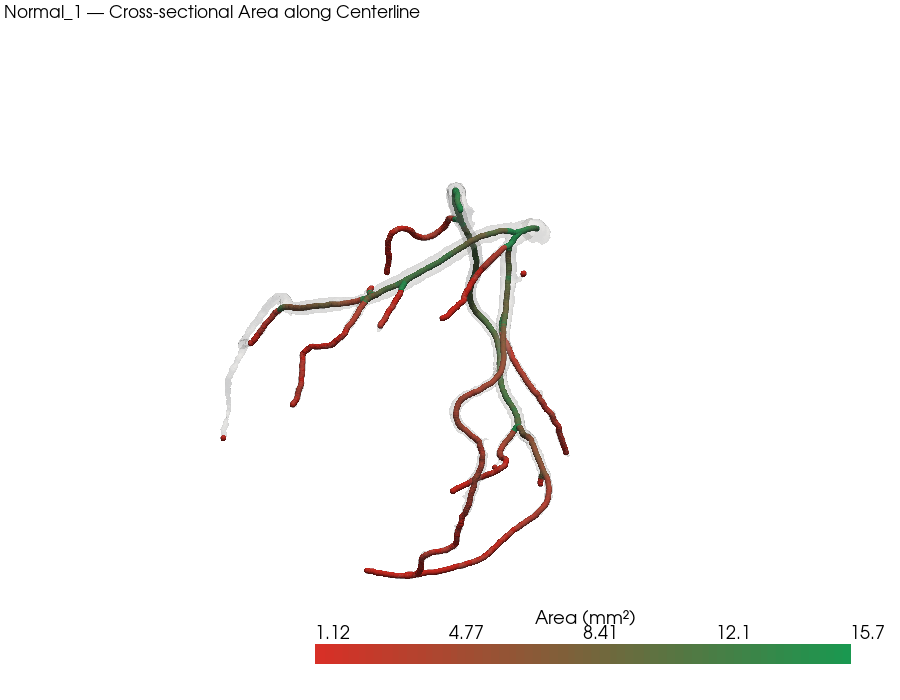

In [13]:
# ── 5a. 3D Overview — mesh + centerline colored by Area ────────────────
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

plotter = pv.Plotter(window_size=(900, 700))

for name, surf in surfaces.items():
    plotter.add_mesh(
        pv.wrap(surf),
        opacity=0.15,
        color="lightgray",
        show_edges=False,
        name=f"surface_{name}",
    )

pts    = df[["Px", "Py", "Pz"]].values
areas  = df["Area"].values
points = pv.PolyData(pts)
points["Area"] = areas

# Wider areas (higher values) in green, narrower areas (lower values) in red.
# Use percentile clipping so outliers do not force most points into red.
green_to_red = LinearSegmentedColormap.from_list(
    "green_to_red", ["#d73027", "#1a9850"], N=64
)
vmin = float(np.nanpercentile(areas, 5))
vmax = float(np.nanpercentile(areas, 95))

plotter.add_mesh(
    points,
    scalars="Area",
    cmap=green_to_red,
    clim=[vmin, vmax],
    point_size=6,
    render_points_as_spheres=True,
    nan_color="red",
    scalar_bar_args={"title": "Area (mm²)"},
)
plotter.add_text(
    f"{PATIENT_ID} — Cross-sectional Area along Centerline",
    font_size=11, color="black",
)
plotter.show()

 Color mapping reacts more to local area differences (instead of being dominated by extremes), then keep the same red↔green meaning.

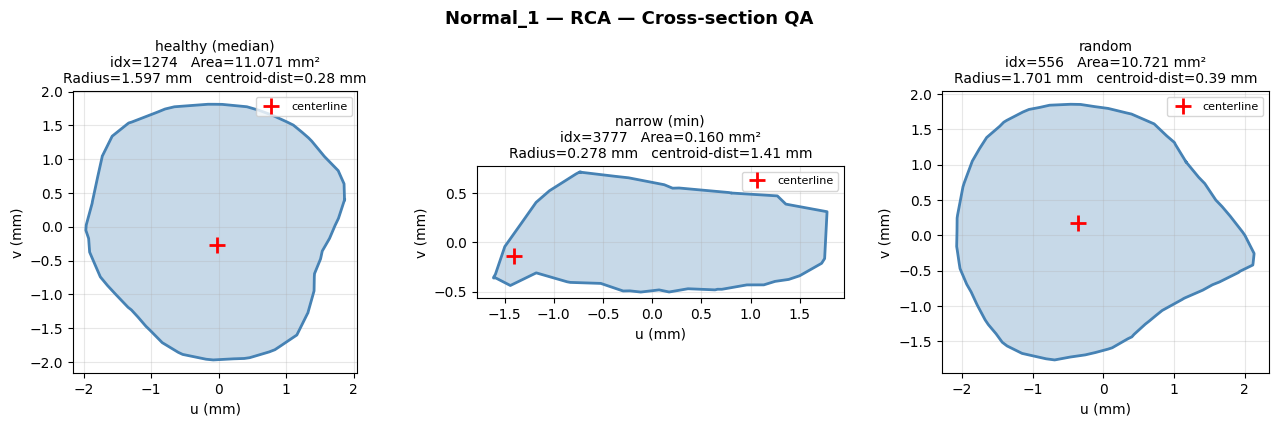

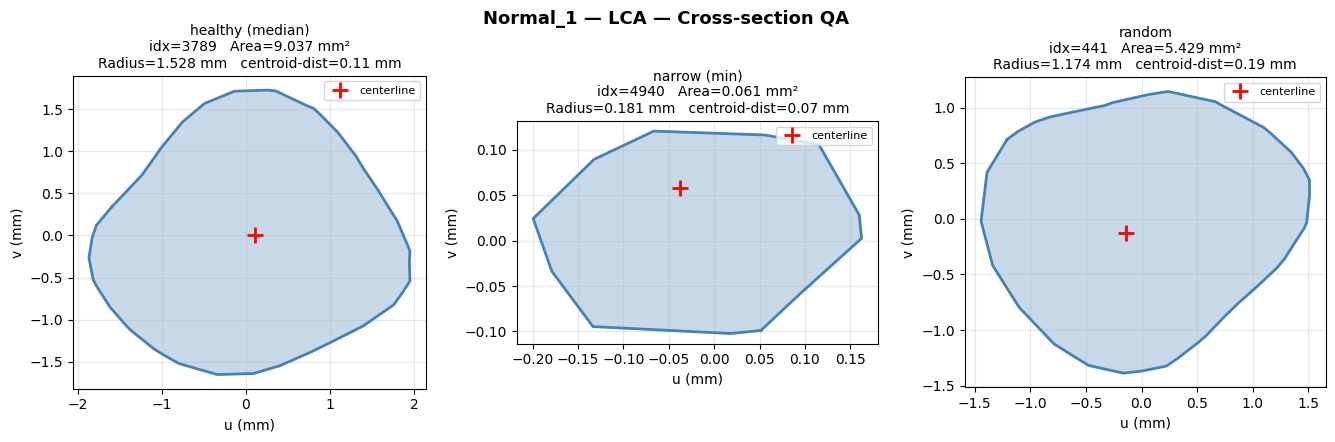

In [10]:
# ── 5b. 2D Cross-section QA plots ─────────────────────────────────────
#
# Strategy per artery (see Section 5c for the full rationale):
#   1. pick three centerline indices — (healthy, narrow, random) — using
#      Area quantiles on the resampled centerline;
#   2. re-cut the smoothed surface mesh at each pick with a plane
#      perpendicular to the local centerline tangent (this reproduces,
#      at plotting time, the slice VMTK used internally to compute Area);
#   3. project that 3D outline onto its best-fit 2D plane and draw it,
#      placing the red '+' at the centerline point projected into the
#      same plane.  The title's Area value is VMTK's, never re-measured.

def pick_qa_indices(area_arr, rng_seed: int = 0):
    """Return dict of {label -> index into area_arr} for QA plots."""
    valid = np.where(np.isfinite(area_arr))[0]
    if valid.size < 3:
        return {}
    a = area_arr[valid]
    rng = np.random.default_rng(rng_seed)

    healthy_idx = valid[int(np.argmin(np.abs(a - np.median(a))))]
    narrow_idx  = valid[int(np.argmin(a))]
    random_idx  = int(rng.choice(valid))
    return {"healthy (median)": healthy_idx,
            "narrow (min)":     narrow_idx,
            "random":           random_idx}


def _centerline_tangent(cl_points, idx):
    """Unit tangent to the centerline at index ``idx`` (central differences,
    one-sided at the endpoints)."""
    n = len(cl_points)
    if idx <= 0:
        v = cl_points[1] - cl_points[0]
    elif idx >= n - 1:
        v = cl_points[-1] - cl_points[-2]
    else:
        v = cl_points[idx + 1] - cl_points[idx - 1]
    norm = np.linalg.norm(v)
    return v / norm if norm > 0 else np.array([0.0, 0.0, 1.0])


def slice_surface_at_point(surface, cl_points, idx):
    """Cut ``surface`` with the plane that passes through ``cl_points[idx]``
    perpendicular to the local centerline tangent, and return the ordered
    3D polyline of the resulting lumen outline.

    Because the cutting plane can also graze neighbouring branches, we keep
    only the contour closest to the centerline point (``ClosestPointRegion``)
    and order its vertices via ``vtkStripper``.

    Returns
    -------
    (polyline_pts, distance_to_centroid) : ((M, 3) ndarray, float)
        or ``(None, inf)`` when the cut fails to produce a usable contour.
    """
    import vtk  # noqa: E402

    p = np.asarray(cl_points[idx], dtype=float)
    n = _centerline_tangent(cl_points, idx)

    plane = vtk.vtkPlane()
    plane.SetOrigin(*p)
    plane.SetNormal(*n)

    cutter = vtk.vtkCutter()
    cutter.SetInputData(surface)
    cutter.SetCutFunction(plane)
    cutter.GenerateTrianglesOff()
    cutter.Update()
    cut = pv.wrap(cutter.GetOutput())
    if cut.n_points == 0:
        return None, np.inf

    conn = vtk.vtkPolyDataConnectivityFilter()
    conn.SetInputData(cut)
    conn.SetExtractionModeToClosestPointRegion()
    conn.SetClosestPoint(*p)
    conn.Update()
    near = pv.wrap(conn.GetOutput()).clean()
    if near.n_points < 3:
        return None, np.inf

    stripper = vtk.vtkStripper()
    stripper.SetInputData(near)
    stripper.JoinContiguousSegmentsOn()
    stripper.Update()
    stripped = pv.wrap(stripper.GetOutput())

    # Follow the first polyline cell to get ordered vertices; if that fails
    # (rare: open contour), fall back to unordered points and let the
    # polar-angle sort in ``project_polygon_to_2d`` recover the outline.
    lines = np.asarray(stripped.lines)
    pts = np.asarray(stripped.points)
    if lines.size > 0:
        npts_cell = int(lines[0])
        order = lines[1:1 + npts_cell]
        ordered = pts[order]
    else:
        ordered = pts

    centroid = ordered.mean(axis=0)
    return ordered, float(np.linalg.norm(centroid - p))


def project_polygon_to_2d(polygon_pts, reference_pt=None, sort_by_angle=False):
    """Project an approximately planar polygon onto its best-fit 2D plane.

    Parameters
    ----------
    polygon_pts : (M, 3) array
        Vertices of the (approximately planar) polygon.
    reference_pt : (3,) array-like, optional
        A 3D point (e.g. the centerline point) to project onto the same
        plane.  Useful for showing where the centerline sits inside the
        cross-section.
    sort_by_angle : bool
        If ``True``, reorder ``pts2d`` by polar angle about the centroid.
        Use this **only** when the input points are unordered (e.g. raw
        vertex cloud).  When the input already comes from ``vtkStripper``
        or is otherwise ordered, leave this ``False`` so that non-convex
        outlines (typical of stenotic lumens) are preserved.

    Returns
    -------
    (pts2d, ref2d) : ((M, 2) array, (2,) array or None)
    """
    center = polygon_pts.mean(axis=0)
    centered = polygon_pts - center
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    basis_2d = vt[:2]
    pts2d = centered @ basis_2d.T

    if sort_by_angle:
        angles = np.arctan2(pts2d[:, 1], pts2d[:, 0])
        pts2d = pts2d[np.argsort(angles)]

    ref2d = None
    if reference_pt is not None:
        ref2d = (np.asarray(reference_pt) - center) @ basis_2d.T
    return pts2d, ref2d


for name, cl_pv in centerlines_with_area.items():
    area = areas_per_artery[name]
    picks = pick_qa_indices(area, rng_seed=42)
    if not picks:
        print(f"[{name}] not enough valid sections for QA plots.")
        continue

    cl_points = np.asarray(cl_pv.points)
    surface   = surfaces[name]

    fig, axes = plt.subplots(1, len(picks),
                             figsize=(4.5 * len(picks), 4.2),
                             squeeze=False)
    fig.suptitle(f"{PATIENT_ID} — {name} — Cross-section QA",
                 fontsize=13, fontweight="bold")

    for ax, (label, idx) in zip(axes[0], picks.items()):
        cl_pt = cl_points[idx]
        poly_pts, d = slice_surface_at_point(surface, cl_points, idx)

        if poly_pts is None or len(poly_pts) < 3:
            ax.set_title(f"{label}\nno polygon available")
            ax.axis("off")
            continue

        pts2d, cl_2d = project_polygon_to_2d(poly_pts, reference_pt=cl_pt)
        closed = np.vstack([pts2d, pts2d[0]])

        ax.fill(closed[:, 0], closed[:, 1], alpha=0.30, color="steelblue")
        ax.plot(closed[:, 0], closed[:, 1], "-", color="steelblue", lw=2)
        ax.plot(cl_2d[0], cl_2d[1], "r+", markersize=12,
                markeredgewidth=2, label="centerline")

        area_val = area[idx]

        # Radius must come from the (resampled) centerline polydata, not
        # from the original dataframe: after vmtkCenterlineResampling the
        # centerline has a different point count than df[Artery_Type==name].
        if "MaximumInscribedSphereRadius" in cl_pv.point_data:
            radius_val = float(
                cl_pv.point_data["MaximumInscribedSphereRadius"][idx]
            )
        else:
            radius_val = float("nan")

        ax.set_title(
            f"{label}\nidx={idx}   Area={area_val:.3f} mm²\n"
            f"Radius={radius_val:.3f} mm   centroid-dist={d:.2f} mm",
            fontsize=10,
        )
        ax.set_xlabel("u (mm)")
        ax.set_ylabel("v (mm)")
        ax.set_aspect("equal")
        ax.grid(alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

<a id="qa-interpretation"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">5c. QA Interpretation & Validation</p>

This section documents how the 2D cross-section QA plots above should be read, what we fixed to get them right, and why we trust the resulting `Area` signal for downstream stenosis quantification.

## 5c.1  The `Area` values were always correct

`CenterlineSectionArea` is computed **inside** `vmtkCenterlineSections`. VMTK intersects the surface with the tangent-perpendicular plane at each (resampled) centerline point, triangulates the resulting 2D polygon and sums the triangle areas. That value is written onto the centerline as a per-point scalar and is exactly what we merged into the dataframe as `Area`.

The bugs we fixed in this section were **purely visualisation bugs** — they never touched the numeric `Area` column saved to disk.

## 5c.2  What was wrong with the first 2D plots and how we fixed it

| Stage | What we tried | What happened |
|-------|---------------|---------------|
| 1 | Pick the single cell in `sections_pv` nearest to the centerline and plot it. | All plots came out as triangles. Reason: `sections_pv` stores each section as a **triangulated patch** (~7–8 coplanar triangles), so the nearest-cell pick always returns one triangle, not the whole outline. |
| 2 | Use `vtkPolyDataConnectivityFilter` to group triangles back into sections. | The filter found **one giant region** spanning the whole artery. Reason: adjacent sections in `sections_pv` share vertex IDs inherited from the parent surface mesh, so topologically the whole sections polydata is a single connected component. |
| 3 (working) | Skip `sections_pv` for QA and re-cut the **surface mesh** at each centerline point with a plane whose normal is the local centerline tangent. | Clean, ordered polyline outlines. |

The working helper `slice_surface_at_point` mirrors exactly what VMTK does internally:

1. Local tangent by central differences on the resampled centerline.
2. `vtkPlane` at the centerline point with that tangent as normal.
3. `vtkCutter` on the surface mesh.
4. `vtkPolyDataConnectivityFilter` in `ClosestPointRegion` mode — keeps only the contour around the centerline, discarding accidental cuts through nearby branches.
5. `vtkStripper` to get an ordered closed polyline.
6. SVD-based projection to 2D (both the polygon and the centerline point, so the red `+` lands in the right place).

Because the `Area` in the title is still VMTK's value and the outline is computed from the same `surface`/tangent pair VMTK used, the plotted shape and the displayed number refer to the **same** physical slice.

## 5c.3  Plot semantics

- **One panel = one centerline point** (given by `idx`).
- **Blue filled polygon**: the 2D lumen cross-section at that point — the intersection of the tangent-perpendicular plane with the artery surface mesh.
- **Blue boundary**: traced in the native spatial order (from `vtkStripper`), so non-convex stenotic outlines would be preserved faithfully.
- **Red `+`**: the centerline point projected into the same 2D plane. In a healthy vessel it should sit close to the polygon's centroid.
- **`u, v` axes**: the two in-plane directions from SVD, in millimetres.
- **`Area` in the title**: VMTK's `CenterlineSectionArea` for that centerline point — identical to the `Area` column in the dataframe.

## 5c.4  What is `centroid-dist`?

The 3D Euclidean distance between the centerline point and the centroid of the cross-section polygon.

- In a **healthy, near-circular vessel** the maximum-inscribed-sphere centerline passes almost exactly through the section centroid, so `centroid-dist ≈ 0`.
- It grows when the lumen is **eccentric** (asymmetric plaque), the cutting plane is **tilted** (non-perpendicular — typical near bifurcations or centerline endpoints), or the **tangent is noisy** (finite-difference at a tip).

Therefore `centroid_dist / Radius` is a cheap **per-point trust metric**: ≈0 means a reliable, centered slice; large values flag either a real eccentric stenosis or a geometric artifact. We will reuse it as a filter in the stenosis-detection sub-task.

## 5c.5  Reading this patient's QA (`Normal_1`)

RCA:

| Pick | Area (mm²) | π·R² (mm²) | centroid-dist (mm) | Verdict |
|------|-----------|-----------|--------------------|---------|
| healthy `idx=1274` | 11.07 | 8.01  | 0.28 | clean oval, reliable |
| narrow  `idx=3777` | 0.16  | 0.243 | **1.41** | artifact: oblique cut, plane nearly parallel to vessel axis |
| random  `idx=556`  | 10.72 | 9.09  | 0.39 | clean oval, reliable |

LCA:

| Pick | Area (mm²) | π·R² (mm²) | centroid-dist (mm) | Verdict |
|------|-----------|-----------|--------------------|---------|
| healthy `idx=3789` | 9.04  | 7.33  | 0.11 | near-circular, reliable |
| narrow  `idx=4940` | 0.061 | 0.103 | 0.07 | **real** distal tip (last centerline point); small but well-defined |
| random  `idx=441`  | 5.43  | 4.33  | 0.19 | clean oval, reliable |

Key observation: `Normal_1` is a healthy patient, so the `"narrow (min)"` heuristic cannot show a real stenosis. What it shows instead — an oblique-cut artifact on RCA, a true distal tip on LCA — is exactly what we expect. The three reliable picks all satisfy `A / π·R² ∈ [1.2, 1.4]`, consistent with slightly oval lumens and the maximum-inscribed-sphere radius being a lower bound on the true section radius.

## 5c.6  Is this `Area` signal suitable for stenosis quantification?

**Yes, with straightforward caveats.** Evidence that the signal is trustworthy:

- `A ≈ 1.2–1.4 · π·R²` for every healthy pick.
- `centroid-dist ≈ 0` for every healthy pick.
- Area range (0.06–11 mm²) is physiologically plausible for RCA/LCA.
- `%AS = 1 − A / A_ref` is the modern, CAD-RADS-compatible stenosis metric, and VMTK's `CenterlineSectionArea` is exactly the `A` that formula requires.

Before running stenosis detection on the raw `Area` signal we should:

- **Trim ~1–2 mm at each centerline tip** (unstable tangent → unreliable cut).
- **Flag bifurcation seeds / oblique cuts** via `centroid_dist / Radius > ~0.3` or VMTK's `CenterlineSectionClosed == 0`.
- **Smooth `Area` along the centerline** (Savitzky–Golay or rolling median) before looking for local minima — raw per-point area carries 5–10% noise from the triangulation granularity.
- **Define a healthy reference per artery** (e.g. robust median of the proximal third, outlier-clipped) so `%AS` is well-defined.

These steps belong in the next Block 2 sub-task; the `Area` column produced here is the clean input they need.

<a id="step6"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">6. Export Enriched DataFrame</p>

The final dataframe carries everything the next stenosis-quantification sub-tasks (healthy reference, %DS) will need:

| Column | Description |
|--------|-------------|
| **Patient_ID** | Patient identifier |
| **Artery_Type** | `"RCA"` / `"LCA"` |
| **Px, Py, Pz** | Physical 3D coordinates (mm) of the centerline point |
| **Radius** | Maximum inscribed sphere radius (mm) — Block 1 output |
| **Area** | Cross-sectional lumen area (mm²) — new in Block 2, `NaN` where the section failed |

The file is written as `.xlsx` to match the Block 1 convention (easy spot-inspection in Excel). A `.csv` is trivial to add later if a downstream block prefers it.

In [11]:
from datetime import datetime

out_name = f"df_{PATIENT_ID}_{datetime.now():%Y%m%d}.xlsx"
out_path = B2_DF_DIR / out_name

df.to_excel(out_path, index=False)
print(f"Wrote {out_path}")
print(f"Rows: {len(df):,}   |   NaN areas: {int(df['Area'].isna().sum()):,}")

Wrote C:\Users\adria\OneDrive\Escriptori\UPF'\TFG\UPF_TFGRepository\results\block2_results\dataframes\df_Normal_1_20260421.xlsx
Rows: 7,296   |   NaN areas: 0


<a id="summary"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">Summary & Next Steps</p>

**Outcome of this notebook.** Each centerline row in the Block 1 dataframe now carries a validated `Area (mm²)` column — the physiologically meaningful lumen cross-section at that point, computed by `vmtkCenterlineSections` and visually cross-checked in Section 5. See Section 5c for the trust analysis on this signal.

**Next sub-tasks of Block 2.**

1. Healthy reference radius/area estimation along each artery (rolling / proximal reference).
2. Percentage Area / Diameter Stenosis (%AS / %DS) derivation from `Area` (and `Radius`) against that reference.
3. Branch-wise stenosis localization and a CAD-RADS-compatible summary.

**Ready-to-promote refactors.**

- The cell-level helpers (`rebuild_smooth_surface`, `clean_triangulate_surface`, `prepare_centerline_for_sections`, `compute_centerline_sections`, `extract_area_array`, `slice_surface_at_point`, …) are already organised as pure functions — they can move to `src/blocks/_02_stenosis.py` behind a `run_block2(patient_id)` entry point that mirrors `run_block1`.
- A one-line Block 1 change would remove the NRRD-based mesh reconstruction from this notebook: persist the smoothed surface as `results/block1_results/meshes/surface_<Patient>_<Artery>_<date>.vtp` and replace Section 2b's mesh rebuild with `pv.read(...)`.